# 00 · Extracción — IVR Alkosto (datos junio 2026)

Reemplaza al CSV histórico de Interaxa (`vw_interaxa_detalle_ivr_...csv`) que usaba
`01_Alk_final.ipynb`. Consulta directamente `vw_emt_gc_detalle_ivr` y aplana
`atributos_custom` en columnas `customN`.

**Salida:** `data/00_raw/df_raw_<fecha_inicio>_<fecha_fin>.parquet` — insumo del
Notebook 2 (`02_reconstruccion_traza.ipynb`).

**Requisitos:**
- Archivo `.env` en la raíz del proyecto (mismo nivel que este notebook o un nivel
  arriba) con las credenciales de conexión.
- `pip install python-dotenv psycopg2-binary pandas pyarrow` (pyarrow para exportar
  a parquet; si prefieres solo Excel, puedes omitirlo y usar `.xlsx` al final).

In [ ]:
import os
import warnings
from pathlib import Path

import pandas as pd
import psycopg2
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

### Parámetros del análisis

Ajusta aquí el periodo y la división antes de correr el resto del notebook. Todo lo
que sigue depende de estos valores — no hay rutas ni fechas quemadas más abajo.

In [2]:
# --- Parámetros editables ---
FECHA_INICIO = "2026-06-01"
FECHA_FIN = "2026-06-30"

DIVISIONES = ["Alkosto", "Home,Alkosto", "Alkosto,Home"]

ORGANIZACION = "emtelcosas"

# Carpeta raíz de datos del proyecto (ajusta si tu estructura es distinta)
DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
RAW_DIR = DATA_DIR / "00_raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = RAW_DIR / f"df_raw_{FECHA_INICIO}_{FECHA_FIN}.parquet"
print(f"Salida esperada: {OUTPUT_PATH}")

Salida esperada: data\00_raw\df_raw_2026-06-01_2026-06-30.parquet


### Conexión

In [3]:
load_dotenv()  # busca un archivo .env en el directorio actual o en los padres

DB_USER = os.getenv("IVR_DB_USER")
DB_PASSWORD = os.getenv("IVR_DB_PASSWORD")
DB_HOST = os.getenv("IVR_DB_HOST")
DB_PORT = int(os.getenv("IVR_DB_PORT", "5432"))
DB_NAME = os.getenv("IVR_DB_NAME")

faltantes = [
    nombre
    for nombre, valor in {
        "IVR_DB_USER": DB_USER,
        "IVR_DB_PASSWORD": DB_PASSWORD,
        "IVR_DB_HOST": DB_HOST,
        "IVR_DB_NAME": DB_NAME,
    }.items()
    if not valor
]
if faltantes:
    raise RuntimeError(
        f"Faltan variables de entorno en tu .env: {faltantes}. "
        "Revisa .env para ver los nombres esperados."
    )

In [5]:
con = psycopg2.connect(
    user=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    dbname=DB_NAME,
)

### Consulta parametrizada

Usa placeholders `%s` (psycopg2 los sustituye de forma segura) en vez de f-strings,
para no repetir el patrón de fechas/organización.

In [ ]:
sql_query = """
SELECT *
FROM public.vw_emt_gc_detalle_ivr
WHERE organizacion = %(organizacion)s
  AND division = ANY(%(divisiones)s)
  AND fecha_inicio >= %(fecha_inicio)s
  AND fecha_inicio <= %(fecha_fin)s
ORDER BY fecha_inicio;
"""

params = {
    "organizacion": ORGANIZACION,
    "divisiones": DIVISIONES,
    "fecha_inicio": FECHA_INICIO,
    "fecha_fin": FECHA_FIN,
}

df = pd.read_sql_query(sql_query, con, params=params)
con.close()
print(df.shape)
df.head(3)

### Chequeos rápidos de sanidad

Antes de aplanar `atributos_custom`, valida que la extracción trajo lo esperado:
que no venga vacía, que las fechas caigan dentro del rango pedido y que
`id_conversacion` no tenga duplicados exactos.

In [39]:
assert len(df) > 0, "La consulta no trajo filas — revisa parámetros de fecha/división."

print("Filas:", len(df))
print("id_conversacion únicos:", df["id_conversacion"].nunique())
print("Duplicados exactos de id_conversacion:", df["id_conversacion"].duplicated().sum())
print("Rango fecha_inicio:", df["fecha_inicio"].min(), "→", df["fecha_inicio"].max())
print("Divisiones encontradas:", df["division"].unique())
print("\nNulos en traza_opciones:", df["traza_opciones"].isna().sum())

Filas: 105499
id_conversacion únicos: 105499
Duplicados exactos de id_conversacion: 0
Rango fecha_inicio: 2026-06-01 → 2026-06-30
Divisiones encontradas: <ArrowStringArray>
['Alkosto']
Length: 1, dtype: str

Nulos en traza_opciones: 8348


### Aplanado de `atributos_custom`

Cada fila trae un dict con claves `customN`, cada una con un único paso `codigo;texto;tiempo`. Los separamos en
columnas propias para poder reconstruir la traza completa en el Notebook 2.

In [ ]:
df_flat = df.join(df["atributos_custom"].apply(pd.Series))

columnas_custom = [c for c in df_flat.columns if c.startswith("custom")]
print(df_flat.shape)
print(f"Columnas custom encontradas ({len(columnas_custom)}):", sorted(columnas_custom))
df_flat[["id_conversacion", "traza_opciones"] + columnas_custom].head(3)

### Exportar

Se guarda en `data/00_raw/` con el rango de fechas en el nombre, para poder tener
varias extracciones (distintos periodos) sin pisarlas entre sí. `parquet`
preserva mejor los tipos (fechas, dict) que Excel; si necesitas revisarlo a ojo,
exporta también una copia en `.xlsx` de una muestra pequeña.

In [14]:
df_flat.to_parquet(OUTPUT_PATH, index=False)
print(f"Guardado: {OUTPUT_PATH}  ({len(df_flat)} filas)")

# Muestra legible en Excel para revisión manual rápida (primeras 200 filas)
muestra_path = RAW_DIR / f"df_raw_muestra_{FECHA_INICIO}_{FECHA_FIN}.xlsx"
df_flat.head(200).to_excel(muestra_path, index=False)
print(f"Muestra Excel: {muestra_path}")

Guardado: data\00_raw\df_raw_2026-06-01_2026-06-30.parquet  (105499 filas)
Muestra Excel: data\00_raw\df_raw_muestra_2026-06-01_2026-06-30.xlsx


# 01 · Reconstrucción de traza — IVR Alkosto

En el pipeline original, todos los pasos de una interacción (navegación,
validaciones de flujo, llamadas a webservice, paso a asesor) llegaban mezclados
en una sola columna (`opcionesnavegaciontrazaopciones`). En los datos actuales,
la vista los separa: `traza_opciones` trae la navegación principal y cada
columna `customN` trae **un solo paso** adicional (validaciones, resultados de
webservice, etc.).

Confirmamos contra el PDF del flujo (`Flujo_actualizado_Alkosto_corte_28-04-26`)
que esos pasos de `customN` **sí son nodos de decisión reales** del árbol (carriles
"API": `¿Error de consulta?`, `¿Estado Fraude?`, `¿Tiene PEA?`, etc.), así que se
integran todos — no se excluyen.

**Entrada:** parquet generado por `00_extraccion.ipynb`.

**Salida:**
- `df_pasos_<periodo>.parquet` — formato largo (un paso por fila), ya con el orden
  cronológico correcto. Este es el insumo directo del Notebook 3 (reemplaza el
  `split('|')` + `stack()` que hacía `01_Alk_final.ipynb` sobre la columna cruda).
- `df_traza_completa_<periodo>.parquet` — un renglón por `id_conversacion` con la
  traza reconstruida como string `|codigo;texto;tiempo|...`, solo para auditoría /
  comparación visual contra `traza_opciones` original.

In [61]:
import warnings
from pathlib import Path

import pandas as pd
from tqdm import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
tqdm.pandas()

### Parámetros — deben coincidir con los usados en `00_extraccion.ipynb`

In [62]:
FECHA_INICIO = "2026-06-01"
FECHA_FIN = "2026-06-30"

DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
RAW_DIR = DATA_DIR / "00_raw"
STAGE_DIR = DATA_DIR / "01_staging"
STAGE_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = RAW_DIR / f"df_raw_{FECHA_INICIO}_{FECHA_FIN}.parquet"
OUT_PASOS_PATH = STAGE_DIR / f"df_pasos_{FECHA_INICIO}_{FECHA_FIN}.parquet"
OUT_TRAZA_PATH = STAGE_DIR / f"df_traza_{FECHA_INICIO}_{FECHA_FIN}.parquet"

assert INPUT_PATH.exists(), f"No encuentro {INPUT_PATH} — corre primero 01_extraccion.ipynb"
print(f"Leyendo: {INPUT_PATH}")

Leyendo: data\00_raw\df_raw_2026-06-01_2026-06-30.parquet


In [63]:
df = pd.read_parquet(INPUT_PATH)
print(df.shape)

ID_COL = "id_conversacion"
COL_TRAZA_PRINCIPAL = "traza_opciones"
columnas_custom = sorted(
    [c for c in df.columns if c.startswith("custom") and c not in ("custom_50",)],
    key=lambda c: int(c.replace("custom", "")) if c.replace("custom", "").isdigit() else 999,
)
print("Columnas fuente que se van a integrar:", [COL_TRAZA_PRINCIPAL] + columnas_custom)

(105499, 42)
Columnas fuente que se van a integrar: ['traza_opciones', 'custom2', 'custom3', 'custom11', 'custom15', 'custom16', 'custom21', 'custom22', 'custom24', 'custom25', 'custom26', 'custom28', 'custom29', 'custom30', 'custom31', 'custom32', 'custom33', 'custom34', 'custom47', 'custom48']


In [65]:
# Filtrar dejando solo llamadas válidas del flujo principal
df = df[df["traza_opciones"].notna()].copy()
df.shape

(97151, 42)

In [66]:
assert len(df) > 0, "La consulta no trajo filas — revisa parámetros de fecha/división."

print("Filas:", len(df))
print("id_conversacion únicos:", df["id_conversacion"].nunique())
print("Duplicados exactos de id_conversacion:", df["id_conversacion"].duplicated().sum())
print("Rango fecha_inicio:", df["fecha_inicio"].min(), "→", df["fecha_inicio"].max())
print("Divisiones encontradas:", df["division"].unique())
print("\nNulos en traza_opciones:", df["traza_opciones"].isna().sum())

Filas: 97151
id_conversacion únicos: 97151
Duplicados exactos de id_conversacion: 0
Rango fecha_inicio: 2026-06-01 → 2026-06-30
Divisiones encontradas: <ArrowStringArray>
['Alkosto']
Length: 1, dtype: str

Nulos en traza_opciones: 0


In [67]:
def separar_traza(traza):
    if pd.isna(traza):
        return []

    pasos = []

    # Elimina el primer "|" si existe
    for paso in str(traza).strip("|").split("|"):
        partes = paso.split(";")

        # Tomar el nombre del nodo (segunda posición)
        if len(partes) >= 2:
            pasos.append(partes[1].strip())
        else:
            pasos.append(None)

    return pasos

# Expandir la traza
df_traza = df.copy()

df_traza = df_traza.join(
    df_traza["traza_opciones"].apply(separar_traza).apply(pd.Series)
)

# Renombrar columnas
columnas = [c for c in df_traza.columns if isinstance(c, int)]

df_traza.rename(
    columns={i: f"traza_{i+1}" for i in columnas},
    inplace=True
)

columnas_traza = [c for c in df_traza.columns if c.startswith("traza_")]

print(df_traza.shape)
print(f"Número de pasos máximos: {len(columnas_traza)}")

df_traza[["id_conversacion"] + columnas_traza]
df_traza.head(3)

(97151, 86)
Número de pasos máximos: 45


,organizacion,id_conversacion,ani,dnis,division,nombre_ivr,fecha_hora_ingreso,fecha_hora_fin,duracion_ivr,duracion_navegacion,duracion_transaccional,duracion_paso_ce,duracion_desborde,traza_opciones,ultima_opcion,tipo_ult_opcion,paso_ce,tipo_desconexion,id_campana,atributos_custom,custom_50,fecha_inicio,fecha_fin,custom2,custom16,custom21,custom22,custom28,custom29,custom30,custom3,custom11,custom15,custom24,custom25,custom32,custom34,custom47,custom31,custom33,custom26,custom48,traza_1,traza_2,traza_3,traza_4,traza_5,traza_6,traza_7,traza_8,traza_9,traza_10,traza_11,traza_12,traza_13,traza_14,traza_15,traza_16,traza_17,traza_18,traza_19,traza_20,traza_21,traza_22,traza_23,traza_24,traza_25,traza_26,traza_27,traza_28,traza_29,traza_30,traza_31,traza_32,traza_33,traza_34,traza_35,traza_36,traza_37,traza_38,traza_39,traza_40,traza_41,traza_42,traza_43,traza_44
0,emtelcosas,891f883b-e8c0-4a43-91a8-00f93459a745,+573212202672,+576014073033,Alkosto,"ALK_IVR_PRINCIPAL,Default In-Queue Flow Alkost...",2026-06-01 18:51:32.530,2026-06-01 19:03:54.720,185663,185095.0,1496.0,284.0,0.0,|0;Inicio IVR ;0|3;Habeas data positivo;48030|...,1003;Finalización por fin de flujo;31,None,SI,System,None,{'custom2': '|2;Numero documento ingresado;102...,None,2026-06-01,2026-06-01,|2;Numero documento ingresado;1023941473,|12;Usuario_Identificado_Con_ANI;NO,|101;Consulta ws ActualizaHabeasData;FAILURE,|100;Consulta ws ConsultaHabeasData;FAILURE,|107;Consulta ws CheckAftersalesCases;OK,|108;Consulta ws GetClientByAni;NOK,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inicio IVR,Habeas data positivo,Menu principal,Garantias y devoluciones,Repetir informacion,Repeat,Iniciar_Tu_Garantia,Igual_O_Menor_30_Dias,Producto_Deteriorado,Gran_Tamano,Paso agente garantias,Bienvenida encuesta SAC,Primera pregunta SAC,Segunda pregunta SAC,Pasa a buzon = NO,Finalización por fin de flujo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,emtelcosas,a474401c-9cf1-491b-a677-0ac154ac6141,+573156554180,+576014073033,Alkosto,ALK_IVR_PRINCIPAL,2026-06-01 15:31:24.227,2026-06-01 15:32:22.083,57833,57301.0,1301.0,266.0,0.0,|0;Inicio IVR ;0|999;No input;14897,999;No input;14897,None,NO,External,None,{'custom2': '|2;Numero documento ingresado;100...,None,2026-06-01,2026-06-01,|2;Numero documento ingresado;1007469531,|12;Usuario_Identificado_Con_ANI;NO,NaN,|100;Consulta ws ConsultaHabeasData;FAILURE,NaN,|108;Consulta ws GetClientByAni;NOK,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inicio IVR,No input,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,emtelcosas,352a5eb7-1bfd-484f-820e-12503f2f8c56,+573146826588,+576014073033,Alkosto,ALK_IVR_PRINCIPAL,2026-06-01 12:23:54.010,2026-06-01 12:34:28.390,36453,34771.0,1682.0,NaN,0.0,|0;Inicio IVR ;0|20;Usuario_Identificado_Con_A...,9;Transferencia Alkosto - Tuya;14753,None,NO,System,None,"{'custom2': None, 'custom16': '|12;Usuario_Ide...",None,2026-06-01,2026-06-01,NaN,|12;Usuario_Identificado_Con_ANI;SI,NaN,NaN,NaN,|108;Consulta ws GetClientByAni;OK,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inicio IVR,Usuario_Identificado_Con_Ani,Solicitud_Para_mi,Menu principal,Transferencia Alkosto - Tuya,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
# --- Extraer columnas de negocio desde customN, y limpiar columnas administrativas ---

def extraer_valor_evento(campo):
    """De un campo tipo '|12;Usuario_Identificado_Con_ANI;NO' devuelve solo el valor final (NO)."""
    if pd.isna(campo):
        return None
    partes = str(campo).strip("|").split(";")
    return partes[-1].strip() if len(partes) >= 2 else None

# Mapa código->nombre de negocio para las columnas que identificamos con certeza a partir del
# PDF de flujo y de los datos de muestra. 
mapa_columnas_negocio = {
    "custom2":  "documento_ingresado",              # ALTA -- confirmado en muestra
    "custom16": "usuario_identificado_ani",          # ALTA -- confirmado en muestra
    "custom21": "ws_actualiza_habeas_data",          # ALTA -- confirmado en muestra
    "custom22": "ws_consulta_habeas_data",           # ALTA -- confirmado en muestra
    "custom28": "ws_check_aftersales_cases",         # ALTA -- confirmado en muestra
    "custom29": "ws_get_client_by_ani",              # ALTA -- confirmado en muestra
    "custom11": "autorizacion_tramite",              # ALTA -- valores SI/NO/SIN AUTORIZACION(ÓN)
    "custom15": "numero_guia_transportadora",        # ALTA -- patrón letra+13 dígitos, típico de guía
    "custom30": "destino_transferencia",             # ALTA -- valores 'Directa_SAMSUNG', 'Asistida_POSVENTA', etc.
    "custom31": "numero_destino_transferencia",      # ALTA -- números telefónicos + 'us.invalid' (error SIP típico)
    "custom47": "marca_producto",                    # ALTA -- valores 'samsung','lg','mabe', etc.
    "custom48": "producto_texto_libre",              # MEDIA -- texto libre tipo 'TCL.', 'Xiaomi.', probablemente dictado por voz
    "custom32": "verificacion_producto_ws",          # MEDIA -- mismo conteo exacto que custom33 (584/233) con OK/FAILURE
    "custom33": "verificacion_producto_flag",        # MEDIA -- versión SI/NO de custom32, mismo conteo -> parecen la misma verificación
    "custom3":  "numero_pedido_ingresado",           # BAJA -- numérico, alta cardinalidad, valores vacíos y '#' (típico de captura DTMF)
    "custom24": "ws_resultado_verificacion_1",       # BAJA -- OK/NOK/FAILURE, no identificado con certeza en el PDF revisado
    "custom25": "ws_resultado_verificacion_2",       # BAJA -- mayoritariamente OK, poca muestra de fallos
    "custom26": "ws_resultado_verificacion_3",       # BAJA -- muy poco frecuente (158 de 105k), casi siempre OK
    "custom34": "ws_resultado_verificacion_frecuente", # BAJA -- es la columna custom más poblada (39.7k), significado sin confirmar
}

for col_origen, col_destino in mapa_columnas_negocio.items():
    if col_origen in df_traza.columns:
        df_traza[col_destino] = df_traza[col_origen].apply(extraer_valor_evento)

# Columnas administrativas / crudas que ya no aportan una vez extraído lo anterior
columnas_a_eliminar = ["organizacion", "dnis", "division", "atributos_custom", "tipo_ult_opcion", "id_campana", "custom_50"] + list(mapa_columnas_negocio.keys())
columnas_a_eliminar = [c for c in columnas_a_eliminar if c in df_traza.columns]
df_traza = df_traza.drop(columns=columnas_a_eliminar)

print(f"Columnas de negocio extraídas ({len(mapa_columnas_negocio)}):", list(mapa_columnas_negocio.values()))
print(f"Columnas eliminadas ({len(columnas_a_eliminar)}):", columnas_a_eliminar)
print(f"Shape resultante: {df_traza.shape}")

Columnas de negocio extraídas (19): ['documento_ingresado', 'usuario_identificado_ani', 'ws_actualiza_habeas_data', 'ws_consulta_habeas_data', 'ws_check_aftersales_cases', 'ws_get_client_by_ani', 'autorizacion_tramite', 'numero_guia_transportadora', 'destino_transferencia', 'numero_destino_transferencia', 'marca_producto', 'producto_texto_libre', 'verificacion_producto_ws', 'verificacion_producto_flag', 'numero_pedido_ingresado', 'ws_resultado_verificacion_1', 'ws_resultado_verificacion_2', 'ws_resultado_verificacion_3', 'ws_resultado_verificacion_frecuente']
Columnas eliminadas (26): ['organizacion', 'dnis', 'division', 'atributos_custom', 'tipo_ult_opcion', 'id_campana', 'custom_50', 'custom2', 'custom16', 'custom21', 'custom22', 'custom28', 'custom29', 'custom11', 'custom15', 'custom30', 'custom31', 'custom47', 'custom48', 'custom32', 'custom33', 'custom3', 'custom24', 'custom25', 'custom26', 'custom34']
Shape resultante: (97151, 79)


In [69]:
df_traza.head(3)

,id_conversacion,ani,nombre_ivr,fecha_hora_ingreso,fecha_hora_fin,duracion_ivr,duracion_navegacion,duracion_transaccional,duracion_paso_ce,duracion_desborde,traza_opciones,ultima_opcion,paso_ce,tipo_desconexion,fecha_inicio,fecha_fin,traza_1,traza_2,traza_3,traza_4,traza_5,traza_6,traza_7,traza_8,traza_9,traza_10,traza_11,traza_12,traza_13,traza_14,traza_15,traza_16,traza_17,traza_18,traza_19,traza_20,traza_21,traza_22,traza_23,traza_24,traza_25,traza_26,traza_27,traza_28,traza_29,traza_30,traza_31,traza_32,traza_33,traza_34,traza_35,traza_36,traza_37,traza_38,traza_39,traza_40,traza_41,traza_42,traza_43,traza_44,documento_ingresado,usuario_identificado_ani,ws_actualiza_habeas_data,ws_consulta_habeas_data,ws_check_aftersales_cases,ws_get_client_by_ani,autorizacion_tramite,numero_guia_transportadora,destino_transferencia,numero_destino_transferencia,marca_producto,producto_texto_libre,verificacion_producto_ws,verificacion_producto_flag,numero_pedido_ingresado,ws_resultado_verificacion_1,ws_resultado_verificacion_2,ws_resultado_verificacion_3,ws_resultado_verificacion_frecuente
0,891f883b-e8c0-4a43-91a8-00f93459a745,+573212202672,"ALK_IVR_PRINCIPAL,Default In-Queue Flow Alkost...",2026-06-01 18:51:32.530,2026-06-01 19:03:54.720,185663,185095.0,1496.0,284.0,0.0,|0;Inicio IVR ;0|3;Habeas data positivo;48030|...,1003;Finalización por fin de flujo;31,SI,System,2026-06-01,2026-06-01,Inicio IVR,Habeas data positivo,Menu principal,Garantias y devoluciones,Repetir informacion,Repeat,Iniciar_Tu_Garantia,Igual_O_Menor_30_Dias,Producto_Deteriorado,Gran_Tamano,Paso agente garantias,Bienvenida encuesta SAC,Primera pregunta SAC,Segunda pregunta SAC,Pasa a buzon = NO,Finalización por fin de flujo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1023941473,NO,FAILURE,FAILURE,OK,NOK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,a474401c-9cf1-491b-a677-0ac154ac6141,+573156554180,ALK_IVR_PRINCIPAL,2026-06-01 15:31:24.227,2026-06-01 15:32:22.083,57833,57301.0,1301.0,266.0,0.0,|0;Inicio IVR ;0|999;No input;14897,999;No input;14897,NO,External,2026-06-01,2026-06-01,Inicio IVR,No input,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1007469531,NO,NaN,FAILURE,NaN,NOK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,352a5eb7-1bfd-484f-820e-12503f2f8c56,+573146826588,ALK_IVR_PRINCIPAL,2026-06-01 12:23:54.010,2026-06-01 12:34:28.390,36453,34771.0,1682.0,NaN,0.0,|0;Inicio IVR ;0|20;Usuario_Identificado_Con_A...,9;Transferencia Alkosto - Tuya;14753,NO,System,2026-06-01,2026-06-01,Inicio IVR,Usuario_Identificado_Con_Ani,Solicitud_Para_mi,Menu principal,Transferencia Alkosto - Tuya,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI,NaN,NaN,NaN,OK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
df_traza["traza_1"].value_counts(dropna=False)

traza_1
Inicio IVR                      82545
Inicio IVR inbound transfers    12980
Bienvenida encuesta SAC          1203
Bienvenida encuesta SA            423
Name: count, dtype: int64

In [77]:
# valores_filtro = ["Bienvenida encuesta SA", "Bienvenida encuesta SAC"]
# df_filtrado = df_traza[df_traza["traza_1"].isin(valores_filtro)].copy()
# df_filtrado.head(2)

In [78]:
#  Definir los flujos que NO forman parte del flujo principal de navegación
flujos_excluir = ["Bienvenida encuesta SAC", "Bienvenida encuesta SA"]
#  Filtrar dejando solo llamadas válidas del flujo principal
df_traza = df_traza[~df_traza["traza_1"].isin(flujos_excluir)].copy()
df_traza.shape

(95525, 79)

In [34]:
# --- Tiempo de navegación vs. tiempo técnico, y banderas de negocio a partir de customN ---

# La fuente ya separa navegación de lo técnico -- no hace falta reconstruirlo desde customN:
#   duracion_ivr            -> duración total del tramo IVR
#   duracion_navegacion     -> tiempo real que el cliente pasó navegando el menú
#   duracion_transaccional  -> tiempo en pasos transaccionales (ej. consultas, webservices)
#   duracion_paso_ce        -> tiempo específico del paso a asesor (Contact Experience)
#   duracion_desborde       -> tiempo en desborde
df_traza["duracion_tecnica_ms"] = (
    df_traza[["duracion_transaccional", "duracion_paso_ce", "duracion_desborde"]]
    .fillna(0)
    .sum(axis=1)
)
df_traza["pct_tiempo_navegacion"] = (df_traza["duracion_navegacion"] / df_traza["duracion_ivr"] * 100).round(1)
df_traza["pct_tiempo_tecnico"] = (df_traza["duracion_tecnica_ms"] / df_traza["duracion_ivr"] * 100).round(1)

# Banderas de negocio a partir de las columnas ws_* ya extraídas de customN
columnas_ws = [
    "ws_actualiza_habeas_data", "ws_consulta_habeas_data",
    "ws_check_aftersales_cases", "ws_get_client_by_ani",
]
columnas_ws_presentes = [c for c in columnas_ws if c in df_traza.columns]

df_traza["n_ws_llamadas"] = df_traza[columnas_ws_presentes].notna().sum(axis=1)
df_traza["ws_algun_error"] = df_traza[columnas_ws_presentes].apply(
    lambda fila: any(str(v).upper() in ("FAILURE", "NOK") for v in fila if pd.notna(v)), axis=1
)

print(df_traza[["duracion_ivr", "duracion_navegacion", "pct_tiempo_navegacion", "pct_tiempo_tecnico", "n_ws_llamadas", "ws_algun_error"]].describe(include="all"))

         duracion_ivr  duracion_navegacion  pct_tiempo_navegacion  \
count    95525.000000         89977.000000           89977.000000   
unique            NaN                  NaN                    NaN   
top               NaN                  NaN                    NaN   
freq              NaN                  NaN                    NaN   
mean     82850.316723         86170.734843              97.330192   
std      50036.756234         48248.832816               5.872459   
min        433.000000        -32110.000000            -257.600000   
25%      47166.000000         51177.000000              97.800000   
50%      81365.000000         83213.000000              99.000000   
75%     114491.000000        115727.000000              99.400000   
max     451746.000000        450910.000000             100.000000   

        pct_tiempo_tecnico  n_ws_llamadas ws_algun_error  
count         95525.000000   95525.000000          95525  
unique                 NaN            NaN            

In [79]:
# --- df_pasos: una fila por paso de navegación (id_conversacion, bloque, op_num, op_text, op_tiempo) ---

def parsear_pasos(traza):
    """De '|0;Inicio IVR ;0|3;Habeas data positivo;48030|...' devuelve una lista de dicts
    con op_num, op_text, op_tiempo para cada paso, en el orden en que aparecen."""
    if pd.isna(traza):
        return []
    pasos = []
    for seg in str(traza).strip("|").split("|"):
        partes = seg.split(";")
        pasos.append({
            "op_num": partes[0].strip() if len(partes) >= 1 else None,
            "op_text": partes[1].strip() if len(partes) >= 2 else None,
            "op_tiempo": partes[2].strip() if len(partes) >= 3 else None,
        })
    return pasos

registros = []
for id_conv, traza in tqdm(
    zip(df["id_conversacion"], df["traza_opciones"]), total=len(df), desc="Parseando trazas"
):
    for bloque, paso in enumerate(parsear_pasos(traza)):
        registros.append({"id_conversacion": id_conv, "bloque": bloque, **paso})

df_pasos = pd.DataFrame(registros)
df_pasos["op_tiempo"] = pd.to_numeric(df_pasos["op_tiempo"], errors="coerce")

print(f"df_pasos: {df_pasos.shape[0]:,} pasos de {df_pasos['id_conversacion'].nunique():,} conversaciones")
df_pasos.head(10)

Parseando trazas: 100%|██████████| 97151/97151 [00:03<00:00, 31557.18it/s]


df_pasos: 818,010 pasos de 97,151 conversaciones


,id_conversacion,bloque,op_num,op_text,op_tiempo
0,891f883b-e8c0-4a43-91a8-00f93459a745,0,0,Inicio IVR,0
1,891f883b-e8c0-4a43-91a8-00f93459a745,1,3,Habeas data positivo,48030
2,891f883b-e8c0-4a43-91a8-00f93459a745,2,17,Menu principal,346
3,891f883b-e8c0-4a43-91a8-00f93459a745,3,7,Garantias y devoluciones,24254
4,891f883b-e8c0-4a43-91a8-00f93459a745,4,14,Repetir informacion,26061
5,891f883b-e8c0-4a43-91a8-00f93459a745,5,997,Repeat,23
6,891f883b-e8c0-4a43-91a8-00f93459a745,6,523,Iniciar_Tu_Garantia,9781
7,891f883b-e8c0-4a43-91a8-00f93459a745,7,527,Igual_O_Menor_30_Dias,8972
8,891f883b-e8c0-4a43-91a8-00f93459a745,8,540,Producto_Deteriorado,5824
9,891f883b-e8c0-4a43-91a8-00f93459a745,9,528,Gran_Tamano,14839


In [80]:
# --- Chequeo rápido: ¿el parser de df_pasos reconstruye exactamente traza_opciones? ---
# Esto NO genera un archivo nuevo -- es solo una prueba de que parsear_pasos() no perdió ni
# corrompió información. Se corre sobre una muestra para que sea rápido.
#
# Nota: algunas conversaciones tienen traza_opciones nulo (no navegaron nada), así que no
# generan filas en df_pasos. Eso es esperado -- se tratan como traza vacía, no como error.

muestra_ids = df["id_conversacion"].sample(min(2000, len(df)), random_state=42)

def reconstruir(grupo):
    grupo = grupo.sort_values("bloque")
    return "".join(
        f"|{row.op_num};{row.op_text};{'' if pd.isna(row.op_tiempo) else int(row.op_tiempo)}"
        for row in grupo.itertuples()
    )

reconstruido = (
    df_pasos[df_pasos["id_conversacion"].isin(muestra_ids)]
    .groupby("id_conversacion")
    .apply(reconstruir, include_groups=False)
    .reindex(muestra_ids, fill_value="")  # conversaciones sin pasos -> traza vacía, no NaN
)

# Comparamos contra una versión de traza_opciones normalizada de la MISMA forma (quitando
# espacios en cada texto), para que la comparación sea justa y no la ensucie un espacio suelto
def normalizar(traza):
    pasos = parsear_pasos(traza)
    if not pasos:
        return ""
    return reconstruir(pd.DataFrame(pasos).assign(bloque=range(len(pasos))))

original_normalizado = df.set_index("id_conversacion").loc[muestra_ids, "traza_opciones"].apply(normalizar)
original_normalizado.index = muestra_ids  # por si hubiera ids duplicados en el índice tras el .loc

coincide = (reconstruido.values == original_normalizado.values)
print(f"Coinciden {coincide.sum()} de {len(coincide)} ({coincide.mean()*100:.1f}%)")
if not coincide.all():
    print("\nEjemplos que no coinciden (revisar):")
    display(pd.DataFrame({
        "id_conversacion": muestra_ids.values,
        "reconstruido": reconstruido.values,
        "original_normalizado": original_normalizado.values,
    })[~coincide].head(3))

Coinciden 2000 de 2000 (100.0%)


In [62]:
# def parsear_pasos(valor):
#     """Convierte '|cod;texto;tiempo|cod;texto;tiempo' en una lista de tuplas
#     (codigo, texto, tiempo). Ignora vacíos y fragmentos mal formados (no 3 partes).
#     Devuelve también el conteo de fragmentos descartados por mal formados.
#     """
#     if valor is None or (isinstance(valor, float) and pd.isna(valor)):
#         return [], 0
#     partes = str(valor).split("|")
#     pasos = []
#     descartados = 0
#     for parte in partes:
#         parte = parte.strip()
#         if not parte:
#             continue
#         campos = parte.split(";")
#         if len(campos) != 3:
#             descartados += 1
#             continue
#         codigo, texto, tiempo = (c.strip() for c in campos)
#         pasos.append((codigo, texto, tiempo))
#     return pasos, descartados

### Exportar

In [81]:
df_pasos.to_parquet(OUT_PASOS_PATH, index=False)
df_traza.to_parquet(OUT_TRAZA_PATH, index=False)

print("Guardado:")
print(f"  {OUT_PASOS_PATH}    -> {df_pasos.shape}  (largo, insumo del grafo)")
print(f"  {OUT_TRAZA_PATH} -> {df_traza.shape}  (una fila por conversación: métricas de tiempo y banderas de negocio)")

Guardado:
  data\01_staging\df_pasos_2026-06-01_2026-06-30.parquet    -> (818010, 5)  (largo, insumo del grafo)
  data\01_staging\df_traza_2026-06-01_2026-06-30.parquet -> (95525, 79)  (una fila por conversación: métricas de tiempo y banderas de negocio)


In [82]:
# Muestra Excel para revisión manual
muestra_path = STAGE_DIR / f"df_traza_muestra_{FECHA_INICIO}_{FECHA_FIN}.xlsx"
df_traza.head(500).to_excel(muestra_path, index=False)
print(f"Muestra Excel: {muestra_path}")

# Muestra Excel para revisión manual
muestra_path = STAGE_DIR / f"df_pasos_muestra_{FECHA_INICIO}_{FECHA_FIN}.xlsx"
df_pasos.head(500).to_excel(muestra_path, index=False)
print(f"Muestra Excel: {muestra_path}")

Muestra Excel: data\01_staging\df_traza_muestra_2026-06-01_2026-06-30.xlsx
Muestra Excel: data\01_staging\df_pasos_muestra_2026-06-01_2026-06-30.xlsx


# 02 · Segmentación de negocio — IVR Alkosto

Toma `df_pasos` y `df_traza` (salidas de `01_reconstruccion_traza.ipynb`) y construye las
variables de negocio para el tablero de Power BI y para filtrar el grafo por escenario.

A diferencia del pipeline de 2024, **no se usa un maestro de Segmentación/Nodo** -- la
clasificación se deriva directamente de los datos (escenario = primer paso después de "Menu
principal"; resultado = combinación de `paso_ce`, `tipo_desconexion` y `ultima_opcion`).

**Entradas:** `df_pasos_<periodo>.parquet`, `df_traza_<periodo>.parquet`

**Salidas:**
- `df_resumen_<periodo>.parquet` — una fila por conversación: escenario, resultado_final,
  n_pasos, tiempo navegación/técnico, banderas de webservices, recontactos. Insumo del tablero.
- `df_aristas_<periodo>.parquet` — una fila por paso con `op_text` -> `op_text_final`
  (`shift(-1)` dentro de cada conversación). Insumo directo del notebook de grafos.

In [1]:
import warnings
from pathlib import Path
import re

import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

#### Parámetros — deben coincidir con los usados en los notebooks anteriores

In [2]:
FECHA_INICIO = "2026-06-01"
FECHA_FIN = "2026-06-30"

DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
STAGE_DIR = DATA_DIR / "01_staging"
SEG_DIR = DATA_DIR / "02_segmentacion"
SEG_DIR.mkdir(parents=True, exist_ok=True)

IN_PASOS_PATH = STAGE_DIR / f"df_pasos_{FECHA_INICIO}_{FECHA_FIN}.parquet"
IN_TRAZA_PATH = STAGE_DIR / f"df_traza_{FECHA_INICIO}_{FECHA_FIN}.parquet"

OUT_RESUMEN_PATH = SEG_DIR / f"df_resumen_{FECHA_INICIO}_{FECHA_FIN}.parquet"
OUT_ARISTAS_PATH = SEG_DIR / f"df_aristas_{FECHA_INICIO}_{FECHA_FIN}.parquet"

for p in (IN_PASOS_PATH, IN_TRAZA_PATH):
    assert p.exists(), f"No encuentro {p} -- corre primero 01_reconstruccion_traza.ipynb"

In [3]:
df_pasos = pd.read_parquet(IN_PASOS_PATH)
df_traza = pd.read_parquet(IN_TRAZA_PATH)

print(f"df_pasos: {df_pasos.shape}")
print(f"df_traza: {df_traza.shape}")

df_pasos: (818010, 5)
df_traza: (95525, 79)


In [4]:
# 1. Obtener conteo absoluto y relativo (porcentaje) incluyendo NaN
conteo = df_traza['traza_1'].value_counts(dropna=False)
porcentaje = df_traza['traza_1'].value_counts(dropna=False, normalize=True) * 100

# 2. Unir ambos en un único DataFrame resumen
resumen_inicios = pd.DataFrame({
    'Cantidad': conteo,
    'Porcentaje (%)': porcentaje.round(2)
})

# Renombrar el índice NaN para que se visualice claramente
resumen_inicios.index = resumen_inicios.index.fillna('Sin Traza (NaN)')

# 3. Métricas clave
inician_inicio_ivr = (df_traza['traza_1'] == 'Inicio IVR').sum()
inician_otra_forma = ((df_traza['traza_1'] != 'Inicio IVR') & df_traza['traza_1'].notna()).sum()
sin_traza = df_traza['traza_1'].isna().sum()

# --- Resultados ---
print(f"Total llamadas únicas: {len(df_traza)}")
print(f"Inician en 'Inicio IVR': {inician_inicio_ivr}")
print(f"Inician de otra forma: {inician_otra_forma}")
print(f"Sin traza inicial (NaN): {sin_traza}\n")

print("--- Distribución de las opciones de inicio ---")
print(resumen_inicios)

Total llamadas únicas: 95525
Inician en 'Inicio IVR': 82545
Inician de otra forma: 12980
Sin traza inicial (NaN): 0

--- Distribución de las opciones de inicio ---
                              Cantidad  Porcentaje (%)
traza_1                                               
Inicio IVR                       82545           86.41
Inicio IVR inbound transfers     12980           13.59


In [11]:
print(f"df_pasos: {df_pasos.shape}")

df_pasos: (818010, 7)


In [9]:
PATRON_SAC = re.compile(
    r"encuesta|^pregunta.*sac$|^primera pregunta sac$|^segunda pregunta sac$|nps|satisfaccion|pasa a buzon",
    re.IGNORECASE,
)
PATRON_TECNICO = re.compile(
    r"^(?:no input|no match|repeat)$"
    r"|bot_entiende"
    r"|^finalizaci[oó]n por fin de flujo$"
    r"|consulta ws"
    r"|usuario_identificado"
    r"|habeas data"
    r"|numero documento"
    r"|n[uú]mero de factura"
    r"|checkaftersales|getclientbyani|actualizahabeasdata|consultahabeasdata"
    r"|^0$",
    re.IGNORECASE,
)

def clasificar_nodo(texto):
    if pd.isna(texto):
        return "Técnico/Otros"
    texto_str = str(texto).strip()
    if PATRON_SAC.search(texto_str):
        return "Encuesta SAC"
    if PATRON_TECNICO.search(texto_str):
        return "Técnico/Validación"
    return "Navegación/Negocio"

df_pasos["categoria_nodo"] = df_pasos["op_text"].apply(clasificar_nodo)
df_pasos["es_negocio"] = df_pasos["categoria_nodo"] == "Navegación/Negocio"

print(df_pasos["categoria_nodo"].value_counts())
print()
print("Detalle de lo excluido:")
df_pasos.loc[~df_pasos["es_negocio"], "op_text"].value_counts().head(40)

categoria_nodo
Navegación/Negocio    601434
Técnico/Validación    122193
Encuesta SAC           94383
Name: count, dtype: int64

Detalle de lo excluido:


op_text
No input                         31514
Usuario_Identificado_Con_Ani     31034
Bienvenida encuesta SAC          29964
Primera pregunta SAC             29964
Finalización por fin de flujo    18541
Habeas data positivo             15900
Segunda pregunta SAC             14334
Pasa a buzon = NO                12534
Repeat                            8778
Habeas data negativo              7443
Bot_Entiende_Si                   4296
Bienvenida encuesta SA            2736
Pregunta NPS SA                   2736
Bot_Entiende_No                   2429
No match                          2258
Pasa a buzon = SI                 2115
Name: count, dtype: int64

In [10]:
df_pasos

,id_conversacion,bloque,op_num,op_text,op_tiempo,categoria_nodo,es_negocio
0,891f883b-e8c0-4a43-91a8-00f93459a745,0,0,Inicio IVR,0,Navegación/Negocio,True
1,891f883b-e8c0-4a43-91a8-00f93459a745,1,3,Habeas data positivo,48030,Técnico/Validación,False
2,891f883b-e8c0-4a43-91a8-00f93459a745,2,17,Menu principal,346,Navegación/Negocio,True
3,891f883b-e8c0-4a43-91a8-00f93459a745,3,7,Garantias y devoluciones,24254,Navegación/Negocio,True
4,891f883b-e8c0-4a43-91a8-00f93459a745,4,14,Repetir informacion,26061,Navegación/Negocio,True
...,...,...,...,...,...,...,...
818005,e8faf510-ca58-4a86-bab9-a2be6523d81d,4,900,Bienvenida encuesta SAC,590428,Encuesta SAC,False
818006,e8faf510-ca58-4a86-bab9-a2be6523d81d,5,901,Primera pregunta SAC,25,Encuesta SAC,False
818007,e8faf510-ca58-4a86-bab9-a2be6523d81d,6,902,Segunda pregunta SAC,13685,Encuesta SAC,False
818008,e8faf510-ca58-4a86-bab9-a2be6523d81d,7,906,Pasa a buzon = NO,7800,Encuesta SAC,False


#### 1. Escenario y sub-escenario (rama del menú principal, y el paso siguiente)

`escenario` = el `op_text` inmediatamente después de la primera vez que aparece "Menu
principal" en la traza. `subescenario` = el paso siguiente a ese. Ambos se derivan de los
datos, no de una lista fija de nombres -- se adaptan solos si el IVR cambia el texto de las
opciones.

El `subescenario` sirve para dos cosas: enriquecer el tablero (un nivel más de detalle que
"escenario") y para filtrar el grafo cuando un escenario completo queda con demasiados nodos
para ser legible (ver notebook 03).

In [12]:
df_pasos_ord = df_pasos.sort_values(["id_conversacion", "bloque"]).copy()
df_pasos_ord["es_menu_principal"] = df_pasos_ord["op_text"].str.strip().str.lower() == "menu principal"
df_pasos_ord["siguiente_paso"] = df_pasos_ord.groupby("id_conversacion")["op_text"].shift(-1)
df_pasos_ord["paso_subsiguiente"] = df_pasos_ord.groupby("id_conversacion")["op_text"].shift(-2)

niveles = (
    df_pasos_ord[df_pasos_ord["es_menu_principal"]]
    .groupby("id_conversacion")
    .first()[["siguiente_paso", "paso_subsiguiente"]]
    .rename(columns={"siguiente_paso": "escenario", "paso_subsiguiente": "subescenario"})
)
escenarios = niveles["escenario"]
subescenarios = niveles["subescenario"]

print(f"Escenario detectado en {escenarios.notna().sum():,} de {df_traza['id_conversacion'].nunique():,} conversaciones")
escenarios.value_counts().head(15)

Escenario detectado en 69,692 de 95,525 conversaciones


escenario
Entrega y Otros Tramites           21362
Garantias y devoluciones           18507
Información general                10510
Existencia de producto              7381
Agendar servicio de instalación     4101
Repetir informacion                 2960
Transferencia Alkosto - Tuya        2939
No input                            1387
No match                             545
Name: count, dtype: int64

#### 2. Resultado final de la llamada

**~8-9% de las conversaciones no tienen `traza_opciones`** -- el análisis mostró que el 95%
de esos casos no son abandono ni ruido: son llamadas que **nunca pasaron por el IVR**
(`paso_ce = SI`, `duracion_ivr = 0`, `nombre_ivr = "SinEspecificar"`), enrutadas directo a un
asesor. Se conservan y se clasifican aparte -- no se eliminan ni se mezclan con las que sí
navegaron y terminaron en asesor.

Reglas, en orden de prioridad:
1. Sin traza (`paso_por_ivr == False`):
   - `paso_ce == "SI"` o el asesor colgó (`tipo_desconexion == "Agent"`) ->
     **Transferencia directa (sin pasar por IVR)**
   - si no -> **Colgó antes de cualquier navegación**
2. Con traza:
   - bandera de asesor, texto que lo menciona, o `tipo_desconexion == "Agent"` ->
     **Transferido a asesor**
   - hay traza pero `ultima_opcion` no quedó registrada -> **Sin navegación registrada**
     (anomalía de datos, no se asume resuelto sobre un dato faltante)
   - texto de error de flujo -> **Error técnico**
   - "no input" / "no match" -> **Abandono / sin respuesta**
   - finalización explícita del flujo -> **Resuelto en IVR**
   - `tipo_desconexion == "System"` (nodos informativos terminales que cuelgan sin pasar por
     un mensaje de finalización genérico, ej. "Existencia de producto") -> **Resuelto en IVR**
     -- validado contra `duracion_ivr`: mediana similar a la finalización explícita.
   - `tipo_desconexion == "External"` -> **Cliente colgó en navegación**
   - lo que no cae en ninguna regla -> **Otro / sin clasificar** (debería quedar ~vacío).

In [13]:
def parsear_paso_simple(campo):
    """De 'codigo;texto;tiempo' (con o sin '|' inicial) devuelve (codigo, texto)."""
    if pd.isna(campo):
        return None, None
    partes = str(campo).strip("|").split(";")
    codigo = partes[0].strip() if len(partes) >= 1 else None
    texto = partes[1].strip() if len(partes) >= 2 else None
    return codigo, texto

codigos_textos = df_traza["ultima_opcion"].apply(parsear_paso_simple)
df_traza["ultimo_codigo"] = codigos_textos.apply(lambda t: t[0])
df_traza["ultimo_texto"] = codigos_textos.apply(lambda t: t[1])

# ¿La conversación llegó a navegar algo del IVR? (traza_opciones no nulo)
df_traza["paso_por_ivr"] = df_traza["traza_opciones"].notna()

patron_asesor = re.compile(r"paso[_\s]*agente|desborde|transferencia", re.IGNORECASE)

def clasificar_resultado(row):
    # -- Sin traza: la llamada nunca navegó el IVR --
    if not row["paso_por_ivr"]:
        if row["paso_ce"] == "SI" or row["tipo_desconexion"] == "Agent":
            return "Transferencia directa (sin pasar por IVR)"
        return "Colgó antes de cualquier navegación"

    tiene_ultima_opcion = isinstance(row["ultimo_texto"], str) and row["ultimo_texto"] != ""
    texto = row["ultimo_texto"] if tiene_ultima_opcion else ""
    texto_low = texto.lower()

    # 1. Transferido a asesor: bandera explícita, texto que lo menciona, o el asesor colgó
    if row["paso_ce"] == "SI" or patron_asesor.search(texto) or row["tipo_desconexion"] == "Agent":
        return "Transferido a asesor"

    # 2. Hay traza pero no quedó registrado el último paso -- anomalía de datos,
    #    no asumir "resuelto" sobre un dato faltante
    if not tiene_ultima_opcion:
        return "Sin navegación registrada"

    # 3. Error de flujo (antes que 'finaliz' genérico, porque el texto de error también lo contiene)
    if "error en el flujo" in texto_low:
        return "Error técnico"

    # 4. Abandono explícito: el cliente no marcó nada o no se le entendió
    if "no input" in texto_low or "no match" in texto_low:
        return "Abandono / sin respuesta"

    # 5. Finalización explícita del flujo (ej. 'Finalización por fin de flujo')
    if "finaliz" in texto_low:
        return "Resuelto en IVR"

    # 6. El sistema cerró la llamada él mismo (no el cliente, no un asesor) -- son nodos
    #    informativos terminales (ej. 'Existencia de producto', 'Fuera de horario default')
    #    que entregan la respuesta y cuelgan sin pasar por un nodo genérico de finalización.
    #    Validado contra duracion_ivr: mediana similar a la finalización explícita.
    if row["tipo_desconexion"] == "System":
        return "Resuelto en IVR"

    # 7. El cliente colgó a mitad de la navegación
    if row["tipo_desconexion"] == "External":
        return "Cliente colgó en navegación"

    return "Otro / sin clasificar"

df_traza["resultado_final"] = df_traza.apply(clasificar_resultado, axis=1)

resumen_resultado = (df_traza["resultado_final"].value_counts(normalize=True) * 100).round(1)
print(resumen_resultado)
print()
print(f"% de llamadas que NUNCA pasaron por el IVR: {(~df_traza['paso_por_ivr']).mean()*100:.1f}%")

resultado_final
Transferido a asesor           61.4
Resuelto en IVR                15.3
Cliente colgó en navegación    14.6
Abandono / sin respuesta        4.7
Error técnico                   3.9
Name: proportion, dtype: float64

% de llamadas que NUNCA pasaron por el IVR: 0.0%


In [14]:
# ¿Los cierres "System" tienen una duración razonable, o hay cortes silenciosos muy cortos?
resuelto_por_sistema = df_traza[
    (df_traza["resultado_final"] == "Resuelto en IVR") & (df_traza["tipo_desconexion"] == "System")
]
resuelto_por_finalizacion = df_traza[
    (df_traza["resultado_final"] == "Resuelto en IVR") & (df_traza["ultimo_texto"].str.lower().str.contains("finaliz", na=False))
]

print("Cierre automático (System) -- duracion_ivr:")
print(resuelto_por_sistema["duracion_ivr"].describe())
print("\nFinalización explícita -- duracion_ivr:")
print(resuelto_por_finalizacion["duracion_ivr"].describe())

Cierre automático (System) -- duracion_ivr:
count     12954.000000
mean      84921.644743
std       35060.007358
min        4225.000000
25%       58358.250000
50%       85065.500000
75%      100640.250000
max      352675.000000
Name: duracion_ivr, dtype: float64

Finalización explícita -- duracion_ivr:
count      5178.000000
mean      96817.461954
std       38723.957286
min        5512.000000
25%       68815.750000
50%       91677.500000
75%      118625.250000
max      360126.000000
Name: duracion_ivr, dtype: float64


In [15]:
# 3. Longitud de la traza (número de pasos)
n_pasos = df_pasos.groupby("id_conversacion").size().rename("n_pasos")
n_pasos.describe()

count    97151.000000
mean         8.419985
std          5.487240
min          1.000000
25%          5.000000
50%          7.000000
75%         11.000000
max         44.000000
Name: n_pasos, dtype: float64

In [16]:
# 4. Recontactos (rellamadas)
df_recontactos = df_traza[["id_conversacion", "ani", "fecha_hora_ingreso", "fecha_hora_fin"]].copy()
df_recontactos["fecha_hora_ingreso"] = pd.to_datetime(df_recontactos["fecha_hora_ingreso"])
df_recontactos["fecha_hora_fin"] = pd.to_datetime(df_recontactos["fecha_hora_fin"])
df_recontactos = df_recontactos.sort_values(["ani", "fecha_hora_ingreso"])

df_recontactos["n_contactos_ani"] = df_recontactos.groupby("ani")["ani"].transform("size")
df_recontactos["numero_llamada"] = df_recontactos.groupby("ani").cumcount() + 1
df_recontactos["horas_desde_contacto_anterior"] = (
    df_recontactos["fecha_hora_ingreso"] - df_recontactos.groupby("ani")["fecha_hora_fin"].shift(1)
).dt.total_seconds() / 3600
df_recontactos["unico_contacto"] = df_recontactos["n_contactos_ani"] <= 1

df_recontactos = df_recontactos[[
    "id_conversacion", "n_contactos_ani", "numero_llamada",
    "horas_desde_contacto_anterior", "unico_contacto",
]]

print(f"Conversaciones con más de un contacto: {(~df_recontactos['unico_contacto']).sum():,} de {len(df_recontactos):,}")

Conversaciones con más de un contacto: 72,060 de 95,525


In [17]:
df_recontactos.head(5)

,id_conversacion,n_contactos_ani,numero_llamada,horas_desde_contacto_anterior,unico_contacto
45016,ce30dc92-cb49-4aed-9dd6-6c7575c4940c,1,1,NaN,True
64048,68565fcf-9f52-43c2-945e-8349d3870199,4,1,NaN,False
60864,4f3e3b59-d698-4965-b1ff-2e51f9f01a53,4,2,4.552831,False
71081,b744bf4b-695b-48f2-ace1-8d4aee15d768,4,3,73.057783,False
76427,609df35c-16fc-486c-b116-d5c91be52113,4,4,18.663950,False


In [18]:
# 5. Consolidar `df_resumen`
df_resumen = (
    df_traza
    .merge(escenarios, on="id_conversacion", how="left")
    .merge(subescenarios, on="id_conversacion", how="left")
    .merge(n_pasos, on="id_conversacion", how="left")
    .merge(df_recontactos, on="id_conversacion", how="left")
)

df_resumen["escenario"] = df_resumen["escenario"].fillna("No llegó al menú principal")
df_resumen["subescenario"] = df_resumen["subescenario"].fillna("Sin sub-escenario")
df_resumen["n_pasos"] = df_resumen["n_pasos"].fillna(0).astype(int)

print(f"df_resumen: {df_resumen.shape}")
df_resumen.head(3)

df_resumen: (95525, 90)


,id_conversacion,ani,nombre_ivr,fecha_hora_ingreso,fecha_hora_fin,duracion_ivr,duracion_navegacion,duracion_transaccional,duracion_paso_ce,duracion_desborde,traza_opciones,ultima_opcion,paso_ce,tipo_desconexion,fecha_inicio,fecha_fin,traza_1,traza_2,traza_3,traza_4,traza_5,traza_6,traza_7,traza_8,traza_9,traza_10,traza_11,traza_12,traza_13,traza_14,traza_15,traza_16,traza_17,traza_18,traza_19,traza_20,traza_21,traza_22,traza_23,traza_24,traza_25,traza_26,traza_27,traza_28,traza_29,traza_30,traza_31,traza_32,traza_33,traza_34,traza_35,traza_36,traza_37,traza_38,traza_39,traza_40,traza_41,traza_42,traza_43,traza_44,documento_ingresado,usuario_identificado_ani,ws_actualiza_habeas_data,ws_consulta_habeas_data,ws_check_aftersales_cases,ws_get_client_by_ani,autorizacion_tramite,numero_guia_transportadora,destino_transferencia,numero_destino_transferencia,marca_producto,producto_texto_libre,verificacion_producto_ws,verificacion_producto_flag,numero_pedido_ingresado,ws_resultado_verificacion_1,ws_resultado_verificacion_2,ws_resultado_verificacion_3,ws_resultado_verificacion_frecuente,ultimo_codigo,ultimo_texto,paso_por_ivr,resultado_final,escenario,subescenario,n_pasos,n_contactos_ani,numero_llamada,horas_desde_contacto_anterior,unico_contacto
0,891f883b-e8c0-4a43-91a8-00f93459a745,+573212202672,"ALK_IVR_PRINCIPAL,Default In-Queue Flow Alkost...",2026-06-01 18:51:32.530,2026-06-01 19:03:54.720,185663,185095.0,1496.0,284.0,0.0,|0;Inicio IVR ;0|3;Habeas data positivo;48030|...,1003;Finalización por fin de flujo;31,SI,System,2026-06-01,2026-06-01,Inicio IVR,Habeas data positivo,Menu principal,Garantias y devoluciones,Repetir informacion,Repeat,Iniciar_Tu_Garantia,Igual_O_Menor_30_Dias,Producto_Deteriorado,Gran_Tamano,Paso agente garantias,Bienvenida encuesta SAC,Primera pregunta SAC,Segunda pregunta SAC,Pasa a buzon = NO,Finalización por fin de flujo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1023941473,NO,FAILURE,FAILURE,OK,NOK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1003,Finalización por fin de flujo,True,Transferido a asesor,Garantias y devoluciones,Repetir informacion,16,1,1,NaN,True
1,a474401c-9cf1-491b-a677-0ac154ac6141,+573156554180,ALK_IVR_PRINCIPAL,2026-06-01 15:31:24.227,2026-06-01 15:32:22.083,57833,57301.0,1301.0,266.0,0.0,|0;Inicio IVR ;0|999;No input;14897,999;No input;14897,NO,External,2026-06-01,2026-06-01,Inicio IVR,No input,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1007469531,NO,NaN,FAILURE,NaN,NOK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,999,No input,True,Abandono / sin respuesta,No llegó al menú principal,Sin sub-escenario,2,1,1,NaN,True
2,352a5eb7-1bfd-484f-820e-12503f2f8c56,+573146826588,ALK_IVR_PRINCIPAL,2026-06-01 12:23:54.010,2026-06-01 12:34:28.390,36453,34771.0,1682.0,NaN,0.0,|0;Inicio IVR ;0|20;Usuario_Identificado_Con_A...,9;Transferencia Alkosto - Tuya;14753,NO,System,2026-06-01,2026-06-01,Inicio IVR,Usuario_Identificado_Con_Ani,Solicitud_Para_mi,Menu principal,Transferencia Alkosto - Tuya,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI,NaN,NaN,NaN,OK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,Transferencia Alkosto - Tuya,True,Transferido a asesor,Transferencia Alkosto - Tuya,Sin sub-escenario,5,3,2,0.037013,False


In [18]:
# Chequeo cruzado rápido: escenario x resultado_final -- para calibrar antes de exportar
pd.crosstab(df_resumen["escenario"], df_resumen["resultado_final"])

resultado_final,Abandono / sin respuesta,Cliente colgó en navegación,Error técnico,Resuelto en IVR,Transferido a asesor
escenario,,,,,
Agendar servicio de instalación,0,0,0,238,3863
Entrega y Otros Tramites,628,1965,2027,2223,14519
Existencia de producto,0,141,564,6676,0
Garantias y devoluciones,292,1607,265,2233,14110
Información general,47,453,10,1341,8659
No input,241,64,20,208,854
No llegó al menú principal,3216,9443,639,761,11774
No match,51,28,22,102,342
Repetir informacion,40,276,89,519,2036


#### 6. Tabla de aristas (origen → destino) para el grafo

`op_text_final` = el siguiente paso dentro de la misma conversación (`shift(-1)`); la última
fila de cada conversación se marca como `"final"`. Esto reemplaza la función
`transformar_dataframe` de `01_Alk_final.ipynb` (2024).

In [20]:
df_aristas = (
    df_pasos[df_pasos["es_negocio"]]
    .sort_values(["id_conversacion", "bloque"])
    .copy()
)
df_aristas["op_text_final"] = df_aristas.groupby("id_conversacion")["op_text"].shift(-1)

ultimas_filas = df_aristas.groupby("id_conversacion").tail(1).index
df_aristas.loc[ultimas_filas, "op_text_final"] = "final"

print(f"df_aristas: {df_aristas.shape}  (de {len(df_pasos):,} pasos totales, {len(df_pasos[df_pasos['es_negocio']]):,} son de negocio)")
df_aristas.head(10)

df_aristas: (601434, 8)  (de 818,010 pasos totales, 601,434 son de negocio)


,id_conversacion,bloque,op_num,op_text,op_tiempo,categoria_nodo,es_negocio,op_text_final
83050,0000b8f3-39e8-4388-aa08-23c0031a9d9f,0,0,Inicio IVR,0,Navegación/Negocio,True,Menu principal
83052,0000b8f3-39e8-4388-aa08-23c0031a9d9f,2,17,Menu principal,604,Navegación/Negocio,True,Agendar servicio de instalación
83053,0000b8f3-39e8-4388-aa08-23c0031a9d9f,3,11,Agendar servicio de instalación,18954,Navegación/Negocio,True,Paso agente instalaciones
83054,0000b8f3-39e8-4388-aa08-23c0031a9d9f,4,206,Paso agente instalaciones,124,Navegación/Negocio,True,final
763038,0001de09-fc90-45b0-a909-29c583544af1,0,0,Inicio IVR,0,Navegación/Negocio,True,final
89983,0001f83b-86fd-464d-a881-df45bb9181bf,0,0,Inicio IVR,0,Navegación/Negocio,True,Menu principal
89984,0001f83b-86fd-464d-a881-df45bb9181bf,1,17,Menu principal,16586,Navegación/Negocio,True,Entrega y Otros Tramites
89985,0001f83b-86fd-464d-a881-df45bb9181bf,2,161,Entrega y Otros Tramites,10688,Navegación/Negocio,True,Estado de entrega
89986,0001f83b-86fd-464d-a881-df45bb9181bf,3,6,Estado de entrega,8862,Navegación/Negocio,True,¿Factura encontrada? = SI
89987,0001f83b-86fd-464d-a881-df45bb9181bf,4,301,¿Factura encontrada? = SI,1637,Navegación/Negocio,True,¿Total de facturas mayor a uno? = SI


#### 7. Exportar

In [21]:
df_resumen.to_parquet(OUT_RESUMEN_PATH, index=False)
df_aristas.to_parquet(OUT_ARISTAS_PATH, index=False)

print("Guardado:")
print(f"  {OUT_RESUMEN_PATH} -> {df_resumen.shape}  (insumo del tablero Power BI)")
print(f"  {OUT_ARISTAS_PATH} -> {df_aristas.shape}  (insumo del grafo, filtrar por escenario aquí)")

# Muestras en Excel para revisión manual
df_resumen.head(500).to_excel(SEG_DIR / f"df_resumen_muestra_{FECHA_INICIO}_{FECHA_FIN}.xlsx", index=False)
df_aristas.head(500).to_excel(SEG_DIR / f"df_aristas_muestra_{FECHA_INICIO}_{FECHA_FIN}.xlsx", index=False)

Guardado:
  data\02_segmentacion\df_resumen_2026-06-01_2026-06-30.parquet -> (95525, 90)  (insumo del tablero Power BI)
  data\02_segmentacion\df_aristas_2026-06-01_2026-06-30.parquet -> (601434, 8)  (insumo del grafo, filtrar por escenario aquí)


# 03 · Grafos de navegación — IVR Alkosto

Toma `df_aristas` y `df_resumen` (salidas de `02_segmentacion.ipynb`) y dibuja el grafo
dirigido de navegación con `graphviz`, igual que `02_Grafos.ipynb` de 2024, pero con dos
diferencias:
- Lee directamente los parquet del pipeline nuevo -- no hace falta generar un Excel filtrado
  por escenario a mano.
- El filtro por escenario (`ESCENARIO`, celda de parámetros) reemplaza el "cambiar la ruta y
  volver a correr" de 2024: se filtra `df_aristas` por `id_conversacion` usando `escenario` de
  `df_resumen` antes de agrupar.

**Entradas:** `df_aristas_<periodo>.parquet`, `df_resumen_<periodo>.parquet`

**Salida:** `.gv` / `.gv.pdf` del grafo (todo el IVR, o un escenario específico).

In [22]:
import re
import graphviz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

#### Parámetros

- `ESCENARIO = None` grafica el IVR completo. Fija un valor exacto de
  `df_resumen["escenario"]` para filtrar a esa rama.
- `SUBESCENARIO = None` -- si el escenario sigue teniendo demasiados nodos, fija además un
  valor exacto de `df_resumen["subescenario"]` (el paso siguiente al escenario) para acotar
  más. Requiere `ESCENARIO` fijado.
- `MIN_FRECUENCIA` -- oculta aristas que ocurrieron menos de N veces. Es el ajuste principal
  para la legibilidad: sube este número si el grafo sigue muy denso.

Corre la celda de abajo para ver las opciones disponibles antes de fijar los valores.

In [48]:
FECHA_INICIO = "2026-06-01"
FECHA_FIN = "2026-06-30"
ESCENARIO = "Existencia de producto"          # ej. "Garantias y devoluciones" -- None = todo el IVR
SUBESCENARIO = None      # ej. "Estado_De_Tu_Garantia" -- requiere ESCENARIO fijado
MIN_FRECUENCIA = 30        # sube este número (ej. 5, 10, 20) si el grafo queda muy denso

DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
SEG_DIR = DATA_DIR / "02_segmentacion"
GRAFOS_DIR = DATA_DIR / "03_grafos"
GRAFOS_DIR.mkdir(parents=True, exist_ok=True)

IN_ARISTAS_PATH = SEG_DIR / f"df_aristas_{FECHA_INICIO}_{FECHA_FIN}.parquet"
IN_RESUMEN_PATH = SEG_DIR / f"df_resumen_{FECHA_INICIO}_{FECHA_FIN}.parquet"

for p in (IN_ARISTAS_PATH, IN_RESUMEN_PATH):
    assert p.exists(), f"No encuentro {p} -- corre primero 02_segmentacion.ipynb"

In [49]:
df_aristas = pd.read_parquet(IN_ARISTAS_PATH)
df_resumen = pd.read_parquet(IN_RESUMEN_PATH)

print(f"df_aristas: {df_aristas.shape}")
print(f"df_resumen: {df_resumen.shape}")

# Menú completo de escenario x subescenario -- de aquí sacas los valores exactos para
# ESCENARIO y SUBESCENARIO en la celda de parámetros. Siempre se imprime, sin importar lo
# que hayas puesto arriba.
menu_escenarios = (
    df_resumen.groupby(["escenario", "subescenario"])
    .size()
    .rename("n_conversaciones")
    .reset_index()
    .sort_values(["n_conversaciones"], ascending=[False])
)
pd.set_option("display.max_rows", 200)
menu_escenarios.head(10)

df_aristas: (601434, 8)
df_resumen: (95525, 90)


,escenario,subescenario,n_conversaciones
44,No llegó al menú principal,Sin sub-escenario,25833
4,Entrega y Otros Tramites,Estado de entrega,14734
15,Garantias y devoluciones,Iniciar_Tu_Garantia,8357
28,Información general,Paso agente SAC,8213
11,Existencia de producto,Sin sub-escenario,6817
1,Agendar servicio de instalación,Paso agente instalaciones,3863
13,Garantias y devoluciones,Estado_De_Tu_Garantia,3705
57,Repetir informacion,Repeat,2960
60,Transferencia Alkosto - Tuya,Sin sub-escenario,2511
5,Entrega y Otros Tramites,Menu principal,2262


### Filtrar por escenario (si aplica) y calcular frecuencia de cada arista

La frecuencia cuenta **ocurrencias del par (origen, destino)**, no conversaciones únicas --
si una llamada pasa dos veces por el mismo par (ej. "Repetir informacion"), cuenta dos veces.
Es la misma lógica que usaba `02_Grafos.ipynb` en 2024 (`groupby().count()`).

In [50]:
mascara = pd.Series(True, index=df_resumen.index)
if ESCENARIO is not None:
    mascara &= df_resumen["escenario"] == ESCENARIO
if SUBESCENARIO is not None:
    assert ESCENARIO is not None, "SUBESCENARIO requiere que fijes ESCENARIO también"
    mascara &= df_resumen["subescenario"] == SUBESCENARIO

ids_filtrados = df_resumen.loc[mascara, "id_conversacion"]
assert len(ids_filtrados) > 0, "El filtro de escenario/subescenario no dejó ninguna conversación"
df_aristas_filtrado = df_aristas[df_aristas["id_conversacion"].isin(ids_filtrados)]

resultado_completo = (
    df_aristas_filtrado
    .groupby(["op_text", "op_text_final"])
    .agg(frecuencia=("id_conversacion", "count"))
    .sort_values("frecuencia", ascending=False)
    .reset_index()
)

resultado = resultado_completo[resultado_completo["frecuencia"] >= MIN_FRECUENCIA]

volumen_total = resultado_completo["frecuencia"].sum()
volumen_mostrado = resultado["frecuencia"].sum()

print(f"Escenario: {ESCENARIO or 'TODO EL IVR'} / Sub-escenario: {SUBESCENARIO or '(todos)'}")
print(f"{df_aristas_filtrado['id_conversacion'].nunique():,} conversaciones")
print(f"Aristas: {len(resultado_completo)} totales -> {len(resultado)} con MIN_FRECUENCIA >= {MIN_FRECUENCIA}")
print(f"Volumen representado: {volumen_mostrado:,} de {volumen_total:,} transiciones ({volumen_mostrado/volumen_total*100:.1f}%)")
resultado.head(10)

Escenario: Existencia de producto / Sub-escenario: (todos)
7,381 conversaciones
Aristas: 59 totales -> 12 con MIN_FRECUENCIA >= 30
Volumen representado: 25,512 de 25,723 transiciones (99.2%)


,op_text,op_text_final,frecuencia
0,Menu principal,Existencia de producto,7381
1,Existencia de producto,final,6817
2,Inicio IVR,Menu principal,5085
3,Solicitud_Para_mi,Menu principal,2084
4,Inicio IVR,Solicitud_Para_mi,2084
5,Existencia de producto,Fuera de horario default,564
6,Finalización por error en el flujo,final,564
7,Fuera de horario default,Finalización por error en el flujo,564
8,Solicitud_Otra_Persona,Menu principal,101
9,Inicio IVR,Solicitud_Otra_Persona,101


### Construir el grafo

Mismo esquema de color que 2024: escala `YlOrRd` normalizada en log sobre el volumen total
que recibe cada nodo, para que los puntos más transitados se vean "más calientes".

In [51]:
import os
os.environ["PATH"] = r"C:\Program Files (x86)\Graphviz\bin" + os.pathsep + os.environ["PATH"]
#Para agregar al path de Windows (PowerShell) y que Graphviz funcione en Jupyter Notebook
# #$env:PATH = "C:\Program Files (x86)\Graphviz\bin;$env:PATH"
#Test-Path "C:\Program Files (x86)\Graphviz\bin\dot.exe"

Guardado: data\03_grafos\grafo_existencia_de_producto_2026-06-01_2026-06-30.gv.pdf


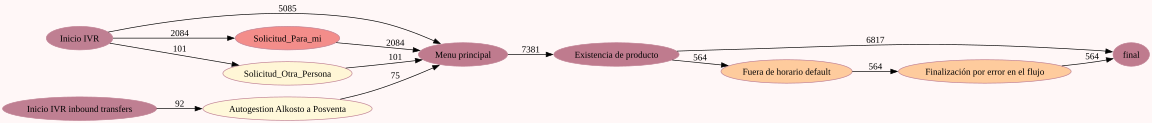

In [52]:
cmap = plt.colormaps["YlOrRd"]
norm = mcolors.Normalize(
    vmin=np.log(resultado["frecuencia"].min()),
    vmax=np.log(resultado["frecuencia"].max()),
)

sufijo = "_".join(filter(None, [ESCENARIO, SUBESCENARIO])) or "todo_ivr"
nombre_archivo = f"grafo_{sufijo.lower().replace(' ', '_')}_{FECHA_INICIO}_{FECHA_FIN}"

u = graphviz.Digraph(
    "ivr",
    filename=str(GRAFOS_DIR / f"{nombre_archivo}.gv"),
    node_attr={"color": "#bf7f92", "style": "filled"},
)
# Con pocos niveles de profundidad (ej. sub-escenarios chicos) 'LR' puede quedar muy ancho y
# aplastado -- si eso pasa, prueba "TB" (arriba-abajo, el original) o ajusta el tamaño abajo.
u.attr(size="16,10")
u.attr(ratio="compress")
u.attr(bgcolor="#fff7f7")
u.attr(rankdir="LR")
u.attr(nodesep="0.25")
u.attr(ranksep="0.6")

for _, fila in resultado.iterrows():
    u.edge(fila["op_text"], fila["op_text_final"], label=str(fila["frecuencia"]))

for nodo_destino in resultado["op_text_final"].unique():
    volumen = resultado.loc[resultado["op_text_final"] == nodo_destino, "frecuencia"].sum()
    color = mcolors.to_hex(cmap(norm(np.log(volumen))))
    u.node(nodo_destino, fillcolor=color + "80")

u.render(cleanup=True)  # genera el .pdf sin intentar abrirlo (usa u.view() si prefieres que se abra)
print(f"Guardado: {GRAFOS_DIR / (nombre_archivo + '.gv.pdf')}")
u

## Tabla de puntos de fuga (por escenario y nodo)

Traduce el grafo a números planos para Power BI: una fila por (`escenario`, `nodo`), con
cuántas veces se llegó a ese nodo y qué pasó después, en 3 grandes grupos:

- **`sigue_navegando`**: la siguiente parada fue otro nodo real del árbol.
- **`va_a_asesor_nodo`**: la siguiente parada es un nodo que ya es de asesor ("Paso agente...",
  "Desborde...", "Transferencia...") -- todavía sigue "dentro" del grafo, no cuelga ahí.
- **`termina_<resultado_final>`**: ese nodo fue el **último** de la conversación (`op_text_final
  == "final"`). En vez de adivinar por el texto del nodo, se usa el `resultado_final` ya
  validado de esa conversación específica (Resuelto en IVR / Transferido a asesor / Abandono /
  Cliente colgó / Error técnico) -- por eso corre después de tener `df_resumen`.

No corre sobre `resultado` (que ya está filtrado por `ESCENARIO`) sino sobre `df_aristas`
completo, para poder comparar puntos de fuga *entre* escenarios en el mismo tablero.

In [ ]:
import re

patron_asesor_nodo = re.compile(r"paso[_\s]*agente|desborde|transferencia", re.IGNORECASE)

mapa_resultado_corto = {
    "Transferido a asesor": "transferido_asesor",
    "Resuelto en IVR": "resuelto_ivr",
    "Cliente colgó en navegación": "colgo_navegacion",
    "Abandono / sin respuesta": "abandono_sin_respuesta",
    "Error técnico": "error_tecnico",
    "Sin navegación registrada": "sin_navegacion_registrada",
    "Otro / sin clasificar": "otro_sin_clasificar",
}

def categoria_salida(fila):
    if fila["op_text_final"] == "final":
        etiqueta = mapa_resultado_corto.get(fila["resultado_final"], "otro_sin_clasificar")
        return f"termina_{etiqueta}"
    if patron_asesor_nodo.search(str(fila["op_text_final"])):
        return "va_a_asesor_nodo"
    return "sigue_navegando"

df_aristas_con_resultado = df_aristas.merge(
    df_resumen[["id_conversacion", "escenario", "resultado_final"]], on="id_conversacion", how="left"
)
df_aristas_con_resultado["categoria_salida"] = df_aristas_con_resultado.apply(categoria_salida, axis=1)

conteo = (
    df_aristas_con_resultado
    .groupby(["escenario", "op_text", "categoria_salida"])
    .size()
    .rename("frecuencia")
    .reset_index()
)

tabla_pivot = conteo.pivot_table(
    index=["escenario", "op_text"], columns="categoria_salida", values="frecuencia", fill_value=0
)
tabla_pivot["llegadas"] = tabla_pivot.sum(axis=1)

pct = tabla_pivot.drop(columns="llegadas").div(tabla_pivot["llegadas"], axis=0) * 100
pct = pct.add_prefix("pct_").round(1)

df_puntos_fuga = pd.concat([tabla_pivot["llegadas"], pct], axis=1).reset_index()
df_puntos_fuga = df_puntos_fuga.rename(columns={"op_text": "nodo"}).sort_values("llegadas", ascending=False)

print(f"{len(df_puntos_fuga)} filas (escenario x nodo)")
df_puntos_fuga.head(15)

In [ ]:
OUT_PUNTOS_FUGA_PATH = GRAFOS_DIR / f"df_puntos_fuga_{FECHA_INICIO}_{FECHA_FIN}.parquet"
df_puntos_fuga.to_parquet(OUT_PUNTOS_FUGA_PATH, index=False)
df_puntos_fuga.to_excel(GRAFOS_DIR / f"df_puntos_fuga_{FECHA_INICIO}_{FECHA_FIN}.xlsx", index=False)
print(f"Guardado: {OUT_PUNTOS_FUGA_PATH} -> {df_puntos_fuga.shape}")

## Tabla de puntos de fuga (para Power BI)

El grafo es para *ver* dónde está la fricción; esta tabla es para *cuantificarla*. Por cada
`(escenario, nodo)` calcula:
- **`llegadas`**: cuántas veces una conversación llegó a ese nodo (desde cualquier origen).
- **% de lo que sale de ese nodo** que:
  - `Continúa en el flujo` -- sigue navegando a otro nodo real.
  - `Transferido a asesor` -- el siguiente paso es un nodo de paso a asesor/desborde/
    transferencia (aplica tanto si es un nodo intermedio como si fue el último paso real de
    la conversación).
  - `Resuelto en IVR`, `Cliente colgó en navegación`, `Abandono / sin respuesta`,
    `Error técnico`, `Sin navegación registrada` -- la conversación **terminó justo en ese
    nodo** (no hay paso siguiente registrado); se usa el `resultado_final` ya calculado en la
    sección 2 para saber cómo terminó exactamente.

Con esto puedes armar directamente un ranking tipo "nodo con más llegadas y mayor % a
asesor" -- los candidatos más claros a mejorar el autoservicio.

In [ ]:
# --- Tabla de puntos de fuga por nodo ---

patron_asesor = re.compile(r"paso[_\s]*agente|desborde|transferencia", re.IGNORECASE)

mapa_escenario = df_resumen.set_index("id_conversacion")["escenario"]
mapa_resultado = df_resumen.set_index("id_conversacion")["resultado_final"]

df_flujo = df_aristas.copy()
df_flujo["escenario"] = df_flujo["id_conversacion"].map(mapa_escenario)

es_final = df_flujo["op_text_final"] == "final"
es_asesor_intermedio = df_flujo["op_text_final"].str.contains(patron_asesor, na=False)

df_flujo["tipo_destino"] = np.select(
    [es_final, es_asesor_intermedio],
    [df_flujo["id_conversacion"].map(mapa_resultado), "Transferido a asesor"],
    default="Continúa en el flujo",
)

# Llegadas: cuántas veces se llegó a cada nodo real (excluye el marcador "final", que no es un nodo)
llegadas = (
    df_flujo[df_flujo["op_text_final"] != "final"]
    .groupby(["escenario", "op_text_final"])
    .size()
    .rename("llegadas")
    .reset_index()
    .rename(columns={"op_text_final": "nodo"})
)

# Salidas: qué pasa con lo que sale de cada nodo, como % del total de salidas de ese nodo
salidas = (
    df_flujo.groupby(["escenario", "op_text", "tipo_destino"])
    .size()
    .rename("volumen")
    .reset_index()
)
tabla_pct = salidas.pivot_table(
    index=["escenario", "op_text"], columns="tipo_destino", values="volumen", fill_value=0
)
tabla_pct["salidas_totales"] = tabla_pct.sum(axis=1)
columnas_pct = [c for c in tabla_pct.columns if c != "salidas_totales"]
tabla_pct[columnas_pct] = tabla_pct[columnas_pct].div(tabla_pct["salidas_totales"], axis=0) * 100
tabla_pct = tabla_pct.round(1).reset_index().rename(columns={"op_text": "nodo"})

tabla_fuga = llegadas.merge(tabla_pct, on=["escenario", "nodo"], how="outer")
tabla_fuga = tabla_fuga.sort_values("llegadas", ascending=False)

print(f"{len(tabla_fuga):,} filas (escenario x nodo)")
tabla_fuga.head(15)

In [ ]:
OUT_FUGA_PATH = GRAFOS_DIR / f"tabla_puntos_fuga_{FECHA_INICIO}_{FECHA_FIN}.parquet"
tabla_fuga.to_parquet(OUT_FUGA_PATH, index=False)
tabla_fuga.to_excel(GRAFOS_DIR / f"tabla_puntos_fuga_{FECHA_INICIO}_{FECHA_FIN}.xlsx", index=False)
print(f"Guardado: {OUT_FUGA_PATH} -> {tabla_fuga.shape}")